In [3]:
import os

for folder in os.listdir("/kaggle/input"):
    print(folder)
    print(os.listdir(f"/kaggle/input/{folder}")[:10])
    print("-"*60)

datasets
['varshavp13', 'shreyaty08']
------------------------------------------------------------


In [6]:
import os

for folder in os.listdir("/kaggle/input/datasets"):
    print("\nFolder:", folder)
    print(os.listdir(f"/kaggle/input/datasets/{folder}")[:10])


Folder: varshavp13
['multimodal-features']

Folder: shreyaty08
['fakeavceleb']


In [9]:
import os

FEATURE_PATH = "/kaggle/input/datasets/varshavp13/multimodal-features"

print(os.listdir(FEATURE_PATH))

['video_features.npy', 'labels.npy', 'audio_features.npy', 'video_names.npy']


In [10]:
import numpy as np

video_features = np.load(
    FEATURE_PATH + "/video_features.npy"
)

audio_features = np.load(
    FEATURE_PATH + "/audio_features.npy"
)

labels = np.load(
    FEATURE_PATH + "/labels.npy"
)

video_names = np.load(
    FEATURE_PATH + "/video_names.npy"
)

print("Video :", video_features.shape)
print("Audio :", audio_features.shape)
print("Labels:", labels.shape)
print("Names :", video_names.shape)

Video : (1000, 768)
Audio : (1000, 768)
Labels: (1000,)
Names : (1000,)


In [11]:
from collections import Counter

print(Counter(labels))

Counter({np.int64(1): 500, np.int64(0): 500})


In [13]:
from sklearn.model_selection import train_test_split

X_video_train, X_video_test, \
X_audio_train, X_audio_test, \
y_train, y_test = train_test_split(
    video_features,
    audio_features,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Video Train :", X_video_train.shape)
print("Video Test  :", X_video_test.shape)

print("Audio Train :", X_audio_train.shape)
print("Audio Test  :", X_audio_test.shape)

print("Train Labels:", y_train.shape)
print("Test Labels :", y_test.shape)

Video Train : (800, 768)
Video Test  : (200, 768)
Audio Train : (800, 768)
Audio Test  : (200, 768)
Train Labels: (800,)
Test Labels : (200,)


In [14]:
X_video_train, X_video_val, \
X_audio_train, X_audio_val, \
y_train, y_val = train_test_split(
    X_video_train,
    X_audio_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Training :", X_video_train.shape)
print("Validation :", X_video_val.shape)
print("Testing :", X_video_test.shape)

Training : (640, 768)
Validation : (160, 768)
Testing : (200, 768)


In [15]:
import torch
from torch.utils.data import Dataset

class MultimodalDataset(Dataset):

    def __init__(self, video, audio, labels):

        self.video = torch.tensor(video, dtype=torch.float32)
        self.audio = torch.tensor(audio, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        return (
            self.video[idx],
            self.audio[idx],
            self.labels[idx]
        )

In [16]:
from torch.utils.data import DataLoader

train_dataset = MultimodalDataset(
    X_video_train,
    X_audio_train,
    y_train
)

val_dataset = MultimodalDataset(
    X_video_val,
    X_audio_val,
    y_val
)

test_dataset = MultimodalDataset(
    X_video_test,
    X_audio_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

20
5
7


In [17]:
import torch
import torch.nn as nn

class EarlyFusionNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.classifier = nn.Sequential(

            nn.Linear(1536,512),

            nn.BatchNorm1d(512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512,256),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256,64),

            nn.ReLU(),

            nn.Linear(64,2)

        )

    def forward(self, video, audio):

        x = torch.cat((video,audio),dim=1)

        return self.classifier(x)

In [18]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = EarlyFusionNet().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print(model)

EarlyFusionNet(
  (classifier): Sequential(
    (0): Linear(in_features=1536, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [19]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for video,audio,label in loader:

        video = video.to(DEVICE)

        audio = audio.to(DEVICE)

        label = label.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(video,audio)

        loss = criterion(outputs,label)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pred = outputs.argmax(1)

        correct += (pred==label).sum().item()

        total += label.size(0)

    return running_loss/len(loader),100*correct/total

In [20]:
def evaluate(model,loader):

    model.eval()

    loss_total = 0

    correct = 0

    total = 0

    preds = []

    actual = []

    with torch.no_grad():

        for video,audio,label in loader:

            video = video.to(DEVICE)

            audio = audio.to(DEVICE)

            label = label.to(DEVICE)

            outputs = model(video,audio)

            loss = criterion(outputs,label)

            loss_total += loss.item()

            pred = outputs.argmax(1)

            preds.extend(pred.cpu().numpy())

            actual.extend(label.cpu().numpy())

            correct += (pred==label).sum().item()

            total += label.size(0)

    return (
        loss_total/len(loader),
        100*correct/total,
        preds,
        actual
    )

In [21]:
EPOCHS = 20

best_acc = 0

for epoch in range(EPOCHS):

    train_loss,train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss,val_acc,_,_ = evaluate(
        model,
        val_loader
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Train Acc {train_acc:.2f}"
        f" | Val Acc {val_acc:.2f}"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_early_fusion.pth"
        )

Epoch 1/20 | Train Acc 63.91 | Val Acc 59.38
Epoch 2/20 | Train Acc 76.25 | Val Acc 72.50
Epoch 3/20 | Train Acc 80.31 | Val Acc 75.00
Epoch 4/20 | Train Acc 83.44 | Val Acc 73.75
Epoch 5/20 | Train Acc 85.78 | Val Acc 77.50
Epoch 6/20 | Train Acc 85.16 | Val Acc 79.38
Epoch 7/20 | Train Acc 87.66 | Val Acc 81.25
Epoch 8/20 | Train Acc 92.34 | Val Acc 83.12
Epoch 9/20 | Train Acc 92.81 | Val Acc 83.75
Epoch 10/20 | Train Acc 95.31 | Val Acc 84.38
Epoch 11/20 | Train Acc 96.41 | Val Acc 83.75
Epoch 12/20 | Train Acc 96.72 | Val Acc 85.62
Epoch 13/20 | Train Acc 97.81 | Val Acc 83.75
Epoch 14/20 | Train Acc 97.81 | Val Acc 83.75
Epoch 15/20 | Train Acc 97.66 | Val Acc 82.50
Epoch 16/20 | Train Acc 97.97 | Val Acc 86.88
Epoch 17/20 | Train Acc 97.81 | Val Acc 85.00
Epoch 18/20 | Train Acc 97.66 | Val Acc 81.88
Epoch 19/20 | Train Acc 98.75 | Val Acc 85.62
Epoch 20/20 | Train Acc 98.44 | Val Acc 84.38


In [22]:
model.load_state_dict(
    torch.load("best_early_fusion.pth")
)

test_loss,test_acc,preds,actual = evaluate(
    model,
    test_loader
)

print(f"\nTest Accuracy : {test_acc:.2f}%")


Test Accuracy : 85.50%


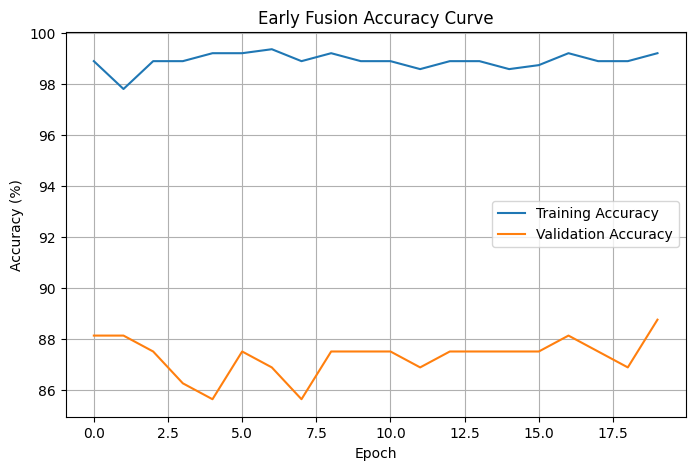

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_acc_history,label="Training Accuracy")
plt.plot(val_acc_history,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Early Fusion Accuracy Curve")

plt.legend()

plt.grid()

plt.show()

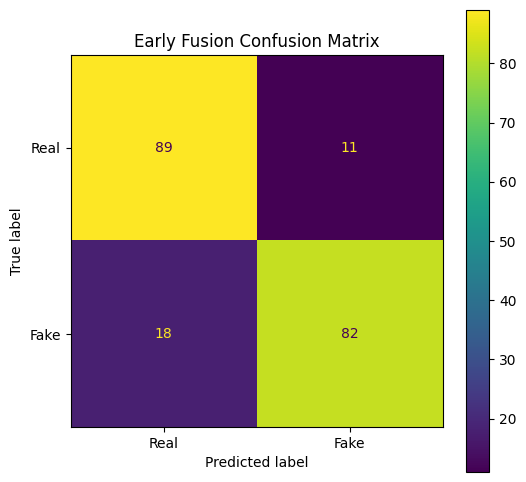

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(actual,preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","Fake"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax)

plt.title("Early Fusion Confusion Matrix")

plt.show()

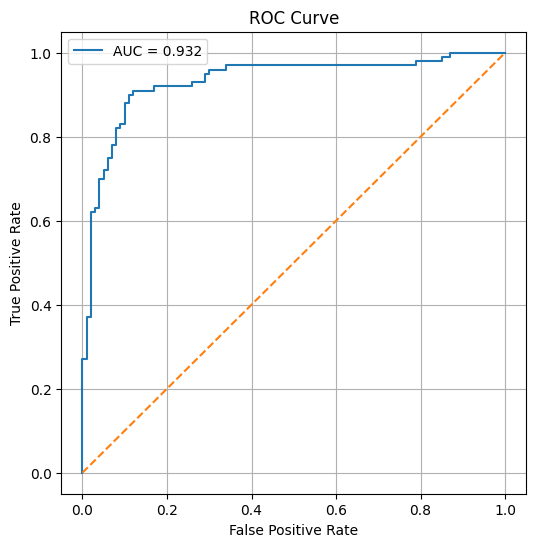

In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.eval()

probabilities = []

with torch.no_grad():

    for video,audio,label in test_loader:

        video = video.to(DEVICE)

        audio = audio.to(DEVICE)

        outputs = model(video,audio)

        prob = torch.softmax(outputs,dim=1)[:,1]

        probabilities.extend(prob.cpu().numpy())

fpr,tpr,_ = roc_curve(actual,probabilities)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

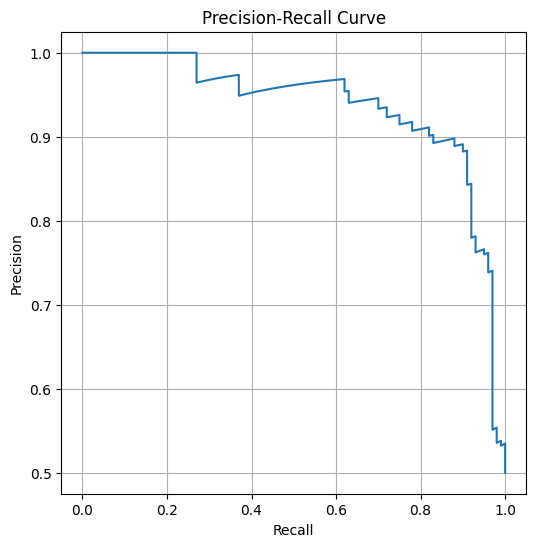

In [29]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    actual,
    probabilities
)

plt.figure(figsize=(6,6))

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.show()

In [30]:
import pandas as pd

results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        test_acc,
        precision_score(actual,preds),
        recall_score(actual,preds),
        f1_score(actual,preds)
    ]

})

print(results)

      Metric      Value
0   Accuracy  85.500000
1  Precision   0.881720
2     Recall   0.820000
3   F1 Score   0.849741
